   match_no day_of_week       date   hour                          venue  \
0         1         Sun  20-Nov-22  17:00                Al Bayt Stadium   
1         2         Mon  21-Nov-22  14:00  Khalifa International Stadium   
2         3         Mon  21-Nov-22  17:00             Al Thumama Stadium   
3         4         Mon  21-Nov-22  20:00          Ahmed bin Ali Stadium   
4         5         Tue  22-Nov-22  11:00          Lusail Iconic Stadium   

                         referee    group              1             2  \
0                 Daniele Orsato  Group A          QATAR       ECUADOR   
1                  Raphael Claus  Group B        ENGLAND          IRAN   
2                 Wilton Sampaio  Group A        SENEGAL   NETHERLANDS   
3  Abdulrahman Ibrahim Al Jassim  Group B  UNITED STATES         WALES   
4                  Slavko Vincic  Group C      ARGENTINA  SAUDI ARABIA   

   attendance  ...  1_panelties_scored  2_panelties_scored  1_goal_prevented  \
0       67372  ...

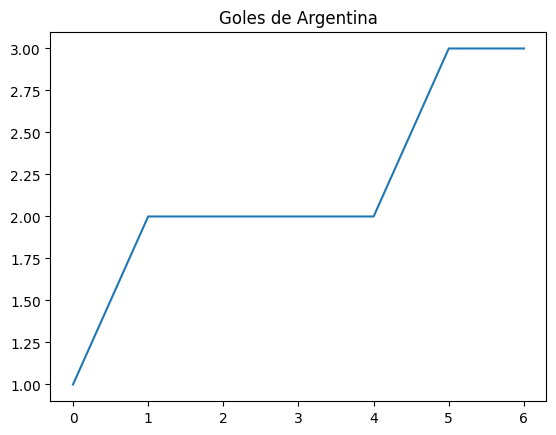

1
ARGENTINA         15
AUSTRALIA          4
BELGIUM            1
BRAZIL             8
CAMEROON           4
CANADA             2
COSTA RICA         3
CROATIA            8
DENMARK            1
ECUADOR            4
ENGLAND           13
FRANCE            16
GERMANY            6
GHANA              5
IRAN               4
JAPAN              5
KOREA REPUBLIC     5
MEXICO             2
MOROCCO            6
NETHERLANDS       10
POLAND             3
PORTUGAL          12
QATAR              1
SAUDI ARABIA       3
SENEGAL            5
SERBIA             5
SPAIN              9
SWITZERLAND        5
TUNISIA            1
UNITED STATES      3
URUGUAY            2
WALES              1
dtype: int64


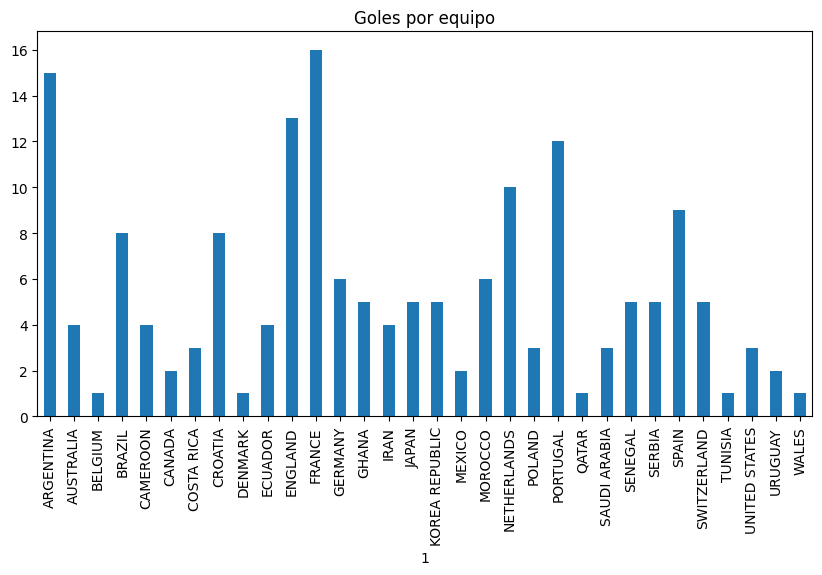

FRANCE
ECUADOR
ENGLAND
NETHERLANDS
Empate
SAUDI ARABIA
Empate
Empate
FRANCE
Empate
JAPAN
SPAIN
BELGIUM
SWITZERLAND
Empate
PORTUGAL
BRAZIL
IRAN
SENEGAL
Empate
Empate
AUSTRALIA
POLAND
FRANCE
ARGENTINA
COSTA RICA
MOROCCO
CROATIA
Empate
Empate
GHANA
BRAZIL
PORTUGAL
NETHERLANDS
SENEGAL
ENGLAND
UNITED STATES
AUSTRALIA
TUNISIA
ARGENTINA
MEXICO
Empate
MOROCCO
JAPAN
GERMANY
URUGUAY
KOREA REPUBLIC
SWITZERLAND
CAMEROON
NETHERLANDS
ARGENTINA
FRANCE
ENGLAND
Empate
BRAZIL
Empate
PORTUGAL
Empate
Empate
MOROCCO
FRANCE
ARGENTINA
FRANCE
CROATIA
Empate


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt



archivo = "https://raw.githubusercontent.com/IgnacioPardo/Tecnologias_Exponenciales_2025/refs/heads/main/qatar.csv"

mundial = pd.read_csv(archivo)

print(mundial.head())



print(len(mundial))


print(mundial.columns)



selecciones = pd.concat([mundial['1'], mundial['2']]).unique()

print(len(selecciones))



print(mundial['attendance'].mean())



mundial['dif_goles'] = abs(mundial['1_goals'] - mundial['2_goals'])

print(mundial[['1', '2', 'dif_goles']])



equipo = 'ARGENTINA'



partidos = mundial[(mundial['1'] == equipo) | (mundial['2'] == equipo)]

print(partidos)



goles = 0

for i, partido in partidos.iterrows():

    if partido['1'] == equipo:
        goles += partido['1_goals']
    else:
        goles += partido['2_goals']

print(goles)



ganados = 0

for i, partido in partidos.iterrows():

    if partido['1'] == equipo and partido['1_goals'] > partido['2_goals']:
        ganados += 1

    if partido['2'] == equipo and partido['2_goals'] > partido['1_goals']:
        ganados += 1

print(ganados)



lista_goles = []

for i, partido in partidos.iterrows():

    if partido['1'] == equipo:
        lista_goles.append(partido['1_goals'])
    else:
        lista_goles.append(partido['2_goals'])

plt.plot(lista_goles)
plt.title('Goles de Argentina')
plt.show()



goles_local = mundial.groupby('1')['1_goals'].sum()
goles_visitante = mundial.groupby('2')['2_goals'].sum()

goles_totales = goles_local + goles_visitante

print(goles_totales)


goles_totales.plot(kind='bar', figsize=(10,5))

plt.title('Goles por equipo')
plt.show()



print(goles_totales.idxmax())



for i, partido in mundial.iterrows():

    if partido['1_goals'] > partido['2_goals']:
        print(partido['1'])

    elif partido['2_goals'] > partido['1_goals']:
        print(partido['2'])

    else:
        print('Empate')

